---

[![Abrir no Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ppestana-supervisor/PDI_python/blob/main/topico2/Topico2.ipynb)

> **Nota importante**
>
> Este notebook é carregado diretamente a partir do repositório oficial no GitHub e é apenas para **leitura**.  
> As alterações **não ficam guardadas**.
>
> Para guardar uma versão pessoal:
> - No Colab, ir a **Ficheiro → Guardar uma cópia no Drive**.  
> - A cópia ficará disponível em `O meu Drive / Colab Notebooks`.
>
> Para colaboração:
> - Abrir a versão pessoal no Google Drive.  
> - Clicar em **Partilhar** → **Qualquer pessoa com o link pode editar** (ou adicionar os colegas manualmente).  
> - A partir daí, todos podem editar em tempo real, como num Google Docs.
>
> Para guardar resultados (imagens, ficheiros, etc.) no  Drive:
> ```python
> from google.colab import drive
> drive.mount('/content/drive')
> ```
> Depois gravar, por exemplo, em:
> ```python
> img.save('/content/drive/MyDrive/PDI_outputs/resultado.png')
> ```

---

# 4.4 Representação e Descrição de Regiões

Depois de segmentar uma imagem — seja por limiarização, deteção de arestas ou operações morfológicas — o passo seguinte consiste em **representar** e **descrever** as regiões obtidas.  
Enquanto a segmentação identifica **onde** estão os objetos, a representação e a descrição procuram responder a **o que são** e **como diferem** entre si.

A **representação** define a forma como cada região é codificada para análise:  
- **Representações de fronteira** descrevem apenas os contornos (por exemplo, cadeias de direções de *Freeman*, polígonos aproximados ou descritores de Fourier).  
- **Representações regionais** descrevem o interior, considerando propriedades geométricas ou topológicas.

A **descrição**, por sua vez, traduz essas representações em **atributos quantitativos** — os chamados *descritores de forma* ou *características regionais* (*region descriptors*).  
Estes descritores permitem comparar, classificar ou reconhecer objetos com base na sua geometria, textura ou estrutura interna.  
Podem ser agrupados em várias categorias:

- **Geométricos** — área, perímetro, compacidade, circularidade, alongamento.  
- **Topológicos** — número de componentes e de buracos (número de Euler).  
- **Estatísticos** — momentos geométricos, invariantes de Hu (rotação, escala, translação).  
- **Frequenciais** — descritores baseados na transformada de Fourier da fronteira.  
- **Texturais** — medidas derivadas da matriz de coocorrência de níveis de cinzento (*GLCM*).

Estas características podem ser combinadas num vetor de atributos, permitindo analisar o **espaço das formas** de forma sistemática e até aplicar métodos de **redução de dimensionalidade** (como a PCA) para visualizar relações de similaridade entre regiões.

Neste capítulo, são exploradas diversas formas de representar e quantificar regiões segmentadas — desde operações simples de medição geométrica até métodos de análise mais abstratos, como momentos e transformadas.  
Tal como nos capítulos anteriores, opta-se por **reimplementações simplificadas**, privilegiando a compreensão intuitiva das operações em detrimento da eficiência computacional.  
O objetivo é consolidar a ligação entre **interpretação visual** e **quantificação matemática** — o ponto onde o processamento de imagem se transforma em análise de padrões.

## 4.4.1.Importar bibliotecas essenciais

Nesta célula são carregadas as bibliotecas essenciais e definidas várias funções auxiliares reutilizáveis, bem como imagens de teste — tanto sintéticas como reais. Este bloco estabelece a infraestrutura para as análises de segmentação, medição e extração de descritores de forma e textura que serão realizadas ao longo do notebook.

#### Bibliotecas

**NumPy** é usada para operações matriciais e criação de imagens binárias.  
**OpenCV (cv2)** fornece funções de desenho e manipulação de formas geométricas, como círculos e polígonos, com elevada eficiência.  
**Collections.deque** é utilizada para implementar filas eficientes no algoritmo de crescimento de regiões.  
**Matplotlib** e **Matplotlib.colors** permitem visualizar imagens e definir colormaps personalizados.  
**scikit-image** disponibiliza ferramentas para medição de propriedades regionais (`measure`), filtragem e limiarização (`filters`), operações morfológicas (`morphology`), e extração de características (`feature`).  
**SciPy.ndimage** acrescenta funções para filtragem e transformações espaciais.  
**Pillow (PIL)** é utilizada para carregar e converter imagens externas.  
**sklearn.decomposition.PCA** é importada para reduzir dimensionalidade e visualizar relações entre descritores morfológicos e geométricos.  

#### Funções Auxiliares

- **`region_growing_label(img_bin, connectivity=8)`** — Implementa o algoritmo clássico de *region growing* (crescimento de regiões) para rotular componentes conexos numa imagem binária, sem recorrer a bibliotecas externas. O parâmetro `connectivity` controla a conectividade (4 ou 8 vizinhos).  

- **`colorize_labels(labels)`** — Converte uma matriz de rótulos em imagem RGB, atribuindo uma cor distinta a cada região com base no colormap *jet*.  

- **`show(img, title=None, ...)`** — Função simples para visualização de imagens, com suporte a escala de cinzentos ou colormaps personalizados.  

- **`overlay(base, mask, alpha=0.5)`** — Combina uma imagem base com uma máscara binária, sobrepondo-a em tons de vermelho com transparência ajustável. Útil para destacar regiões segmentadas sobre a imagem original.  

#### Criação de Imagens Sintéticas

São geradas cinco imagens binárias com geometrias e complexidades variadas:
- `img_multi` — conjunto de múltiplas formas (círculo, retângulo, triângulo e cruz), usado para testar segmentação por crescimento de regiões e rotulagem.  
- `img_square` — quadrado central, base para descritores geométricos e momentos.  
- `img_triangle` — triângulo equilátero alinhado, útil para estudar orientações e simetrias.  
- `img_circle` — círculo perfeito, frequentemente usado como referência para circularidade e compacidade.  
Estas imagens permitem comparar o comportamento de métricas como área, perímetro e excentricidade sob diferentes morfologias.

#### Imagens Importadas

São também carregadas três imagens reais a partir da pasta `imgs/`:
- `img_coins2` — fotografia de moedas, ideal para segmentação e contagem de objetos.  
- `img_rock` — imagem de uma pedra isolada, usada para análise de forma e convexidade.  
- `img_textures2` — padrão complexo, apropriado para análise de textura via matriz de coocorrência (GLCM).  

Estas imagens complementam os padrões sintéticos, permitindo explorar a transição entre dados artificiais e casos práticos reais.

In [1]:
import numpy as np
import cv2
from collections import deque
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import ListedColormap
from skimage import measure, filters, morphology, feature
import scipy.ndimage
from PIL import Image
from skimage.feature import graycomatrix, graycoprops
from sklearn.decomposition import PCA

def region_growing_label(img_bin, connectivity=8):
    """Rotula regiões conectadas numa imagem binária (sem usar cv2 nem skimage)."""
    labeled = np.zeros_like(img_bin, dtype=np.int32)
    label = 0
    h, w = img_bin.shape
    if connectivity == 4:
        neighbors = [(-1,0),(1,0),(0,-1),(0,1)]
    else:
        neighbors = [(-1,0),(1,0),(0,-1),(0,1),(-1,-1),(-1,1),(1,-1),(1,1)]
    for y in range(h):
        for x in range(w):
            if img_bin[y, x] == 1 and labeled[y, x] == 0:
                label += 1
                q = deque([(y, x)])
                labeled[y, x] = label

                while q:
                    cy, cx = q.popleft()
                    for dy, dx in neighbors:
                        ny, nx = cy + dy, cx + dx
                        if 0 <= ny < h and 0 <= nx < w:
                            if img_bin[ny, nx] == 1 and labeled[ny, nx] == 0:
                                labeled[ny, nx] = label
                                q.append((ny, nx))
    return labeled

def colorize_labels(labels):
    n = int(labels.max())
    base_cmap = mpl.colormaps['jet']  
    cmap = ListedColormap(base_cmap(np.linspace(0, 1, n + 1)))  
    rgb = cmap(labels / n)[..., :3]
    return (rgb * 255).astype(np.uint8)

def show(img, title=None, cmap='gray', vmin=0, vmax=None):
    fig, ax = plt.subplots()
    if vmax is not None:
        ax.imshow(img, cmap=cmap, vmin=vmin, vmax=vmax)
    else:
        ax.imshow(img, cmap=cmap, vmin=vmin)
    if title is not None:
        ax.set_title(title)
    ax.axis('off')
    
def overlay(base, mask, alpha=0.5):
    if base.ndim == 2:
        base_rgb = np.stack([base, base, base], axis=2).astype(np.float32)
    else:
        base_rgb = base.astype(np.float32)
    overlay_img = base_rgb.copy()
    overlay_img[mask != 0, 0] = (1 - alpha) * overlay_img[mask != 0, 0] + alpha * 255
    overlay_img[mask != 0, 1:] *= (1 - alpha)
    return overlay_img.astype(base_rgb.dtype)

size = 128

img_multi = np.zeros((size, size), dtype=np.uint8)
cv2.circle(img_multi, (32, 32), 15, 1, -1)
cv2.rectangle(img_multi, (80, 20), (110, 50), 1, -1)
pts = np.array([[64, 90], [48, 120], [80, 120]], np.int32).reshape((-1, 1, 2))
cv2.fillPoly(img_multi, [pts], 1)
img_multi[30:98, 60:68] = 1
img_multi[60:68, 30:98] = 1
img_multi = np.clip(img_multi, 0, 1).astype(np.uint8)

img_square = np.zeros((size, size), dtype=np.uint8)
img_square[size//4:3*size//4, size//4:3*size//4] = 1
img_triangle = np.zeros_like(img_square)
for row in range(size//2):
    start = size//2 - row
    end = size//2 + row
    img_triangle[row + size//4, start:end] = 1
img_circle = np.zeros_like(img_square)
X, Y = np.ogrid[:size, :size]
mask_circ = (X - size//2) ** 2 + (Y - size//2) ** 2 <= (size//4) ** 2
img_circle[mask_circ] = 1

img_coins2 = np.array(Image.open("imgs/coins.png").convert("L"))
img_rock = np.array(Image.open("imgs/rock.png").convert("L"))
img_textures2 = np.array(Image.open("imgs/textures2.png").convert("L"))

## 4.4.2. Etiquetagem e propriedades básicas

Esta célula apresenta uma aplicação de **rotulagem de regiões binárias e extração de métricas geométricas simples** com base em **crescimento de regiões (region growing)**.  
O exemplo demonstra a identificação de formas separadas numa imagem sintética (`img_multi`) e a comparação entre diferentes métodos de rotulagem e análise.

**Descrição sequencial do código**  
1) As regiões são detetadas com `region_growing_label(img_multi)`, retornando uma matriz de rótulos (`labels_shapes`) em que cada região conectada recebe um valor inteiro distinto.  
O número total de regiões é obtido por `num_regions = labels_shapes.max()`.

2) Para **visualização qualitativa**, os rótulos são convertidos em cores pseudoaleatórias:  
`np.mod(labels_shapes * 47, 255)` cria variações cromáticas determinísticas e `cv2.applyColorMap(..., COLORMAP_JET)` aplica uma paleta perceptualmente distinta.  
O resultado é exibido ao lado da imagem binária original, facilitando a contagem e inspeção das regiões separadas.

3) Em seguida, comparam-se três abordagens de **rotulagem de conectividade**:  
- `cv2.connectedComponents(img_multi)` (OpenCV);  
- `measure.label(img_multi, connectivity=2)` (scikit-image);  
- e o método de **region growing** implementado manualmente.  
Os resultados são impressos no terminal, mostrando que os métodos convergem quanto ao número de regiões identificadas, salvo pequenas diferenças de implementação.

4) A função `colorize_labels(labels_shapes)` cria uma versão colorida de alta legibilidade, apresentada pela função `show()`.

5) Calculam-se **área e perímetro** de cada região rotulada:  
- A **área** é o número de píxeis com valor 1 dentro da máscara (`mask.sum()`).  
- O **perímetro** é estimado morfologicamente através da diferença entre uma dilatação e uma erosão binária (`boundary = dil - ero`).  
Esta abordagem aproxima o contorno com boa precisão sem recorrer a funções de alto nível.

6) Por fim, são gerados dois **gráficos de barras** que representam:  
- A **área por região**, útil para verificar proporções relativas.  
- O **perímetro por região**, indicador da complexidade das fronteiras.

**Interpretação e observações**  
- A célula ilustra a **integração entre segmentação e análise geométrica**, aplicável tanto a imagens sintéticas como reais.  
- O uso de três métodos de rotulagem (OpenCV, scikit-image e manual) demonstra a consistência das abordagens e serve como validação cruzada.  
- As medidas de área e perímetro permitem quantificar diferenças morfológicas e identificar regiões atípicas.  
- Este tipo de análise é fundamental em tarefas como **contagem de objetos, caracterização de partículas, ou identificação de componentes em imagens industriais ou biomédicas**.

Em suma, esta célula exemplifica um **pipeline básico de análise de regiões rotuladas**, mostrando desde a segmentação inicial até à avaliação quantitativa das formas detetadas.

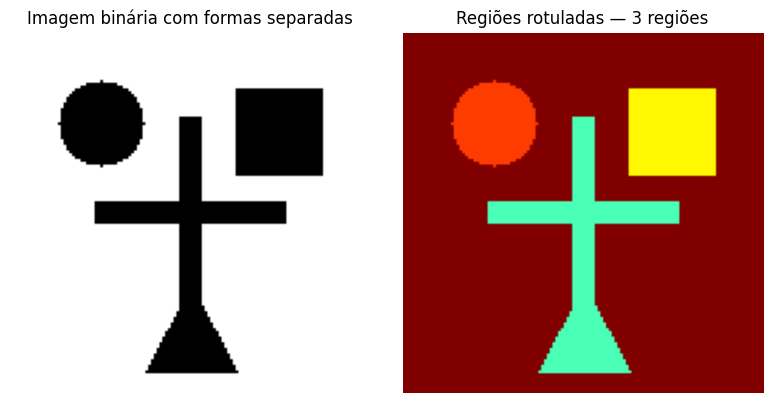

OpenCV: 3 regiões (excluindo fundo)
skimage: 3 regiões


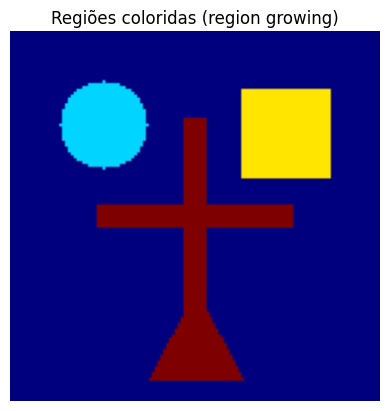

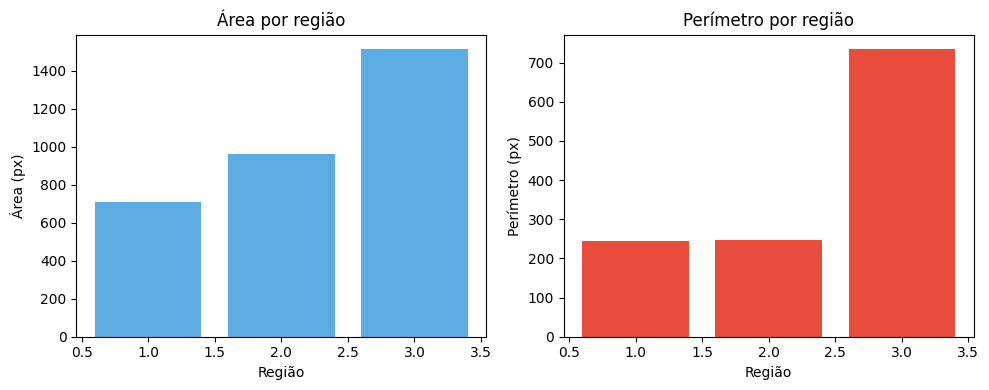

In [2]:
labels_shapes = region_growing_label(img_multi)
num_regions = labels_shapes.max()

color_labels = np.mod(labels_shapes * 47, 255).astype(np.uint8)
color_map = cv2.applyColorMap(color_labels, cv2.COLORMAP_JET)

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(img_multi, cmap='gray_r', vmin=0, vmax=1)
ax[0].set_title('Imagem binária com formas separadas')
ax[0].axis('off')
ax[1].imshow(color_map)
ax[1].set_title(f'Regiões rotuladas — {num_regions} regiões')
ax[1].axis('off')
plt.tight_layout()
plt.show()

n_cv, labels_cv = cv2.connectedComponents(img_multi)
labels_sk = measure.label(img_multi, connectivity=2)
print(f"OpenCV: {n_cv - 1} regiões (excluindo fundo)")
print(f"skimage: {labels_sk.max()} regiões")

colored = colorize_labels(labels_shapes)
show(colored, 'Regiões coloridas (region growing)')

areas, perims = [], []
for lab in range(1, labels_shapes.max() + 1):
    mask = (labels_shapes == lab).astype(np.uint8)
    area = mask.sum()
    dil = scipy.ndimage.binary_dilation(mask, structure=np.ones((3, 3))).astype(np.uint8)
    ero = scipy.ndimage.binary_erosion(mask, structure=np.ones((3, 3))).astype(np.uint8)
    boundary = dil - ero
    perim = boundary.sum()
    areas.append(area)
    perims.append(perim)

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].bar(range(1, len(areas) + 1), areas, color='#5DADE2')
axs[0].set_title('Área por região')
axs[0].set_xlabel('Região')
axs[0].set_ylabel('Área (px)')
axs[1].bar(range(1, len(perims) + 1), perims, color='#E74C3C')
axs[1].set_title('Perímetro por região')
axs[1].set_xlabel('Região')
axs[1].set_ylabel('Perímetro (px)')
plt.tight_layout()
plt.show()

## 4.4.3 Da análise morfológica à extração de propriedades

Esta célula apresenta uma **análise morfológica completa** aplicada à imagem `img_coins2`, demonstrando como combinar **segmentação automática, limpeza, rotulagem e extração de propriedades regionais** para caracterizar objetos individuais (as moedas).

**Descrição sequencial do código**  
1) A imagem é convertida em binária através do método de **Otsu**, que determina automaticamente o limiar $T$ que minimiza a variância intra-classe:  
$$(img > T) \Rightarrow img_{bin}$$  
Este passo separa as moedas (valores altos) do fundo (valores baixos) sem intervenção manual.

2) Realiza-se uma **limpeza morfológica** da imagem binária:  
- `remove_small_objects(..., 3500)` elimina pequenas regiões ruidosas;  
- `remove_small_holes(...)` preenche falhas internas nas moedas.  
O resultado é uma máscara binária limpa, preservando apenas as moedas bem definidas.

3) Segue-se a **rotulagem das regiões conectadas** usando `measure.label(img_clean, connectivity=2)`.  
Cada moeda recebe um rótulo distinto (inteiro positivo) e o número total de regiões é guardado em `num_regions`.

4) Para **visualização**, são criadas duas versões:  
- `colorize_labels(labels)`, que colore as regiões com tons distintos;  
- `overlay(img, labels > 0, alpha=0.4)`, que sobrepõe a máscara colorida à imagem original.  
O resultado permite confirmar visualmente a segmentação e contagem das moedas.

5) Extraem-se **métricas regionais** com `regionprops_table`, incluindo:  
- `area`: número de píxeis da região;  
- `perimeter`: comprimento do contorno;  
- `centroid`: posição $(x, y)$ do centro geométrico;  
- `eccentricity`: grau de alongamento (≈0 circular, ≈1 elíptico);  
- `solidity`: razão entre área e área do casco convexo;  
- `mean_intensity`: média da intensidade original dentro da região.  
Os resultados são armazenados num `DataFrame` do pandas, arredondados para duas casas decimais e exibidos em tabela.

6) Por fim, são criados dois **gráficos-resumo**:  
- O primeiro mostra a **área por região**, útil para avaliar uniformidade de tamanho.  
- O segundo apresenta a **excentricidade**, permitindo identificar moedas deformadas, sobrepostas ou cortadas.

**Interpretação e observações**  
- Esta sequência exemplifica um **pipeline completo de análise de imagem orientado a objetos**, desde a segmentação até à medição quantitativa.  
- O método de Otsu combinado com operações morfológicas assegura uma **segmentação robusta e automática**.  
- As propriedades extraídas permitem caracterizar cada moeda tanto geometricamente (área, forma) como radiometricamente (intensidade média).  
- A análise pode ser facilmente estendida a outros contextos, como **biologia celular, inspeção industrial, ou contagem de partículas**.

Em síntese, esta célula encerra um exemplo prático e interpretável de **extração e quantificação de regiões** em imagens reais, unindo técnicas de processamento e análise estatística de forma integrada.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


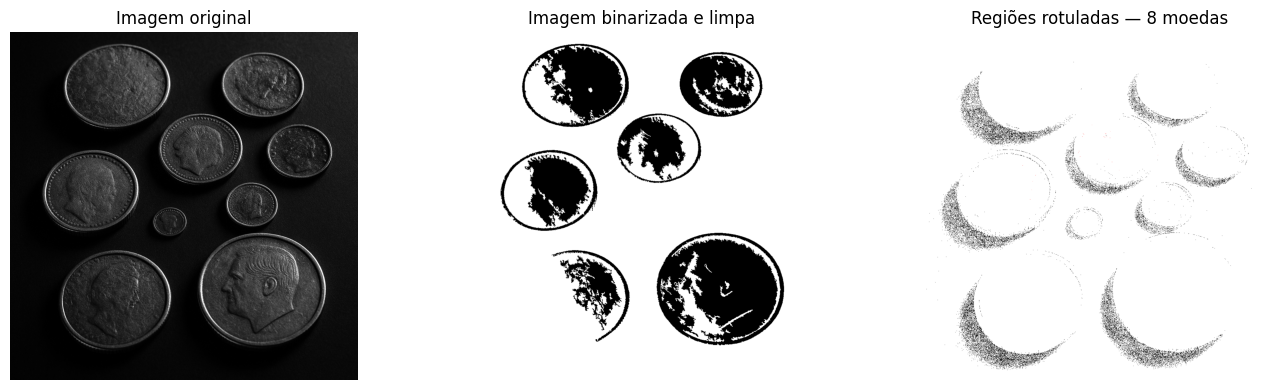

,label,area,perimeter,centroid-0,centroid-1,eccentricity,solidity,mean_intensity
0,1,40895,4486.25,148.04,341.14,0.52,0.67,72.10
1,2,27556,3847.22,152.48,733.74,0.61,0.75,73.02
2,3,22414,3548.36,332.56,551.67,0.62,0.56,71.05
3,4,6233,2021.92,469.19,243.06,0.61,0.12,93.85
4,5,25214,2178.73,459.27,260.62,0.51,0.80,63.65
5,6,77676,6975.10,751.96,748.40,0.56,0.79,69.95
6,7,3803,1152.86,749.95,414.59,0.88,0.10,99.72
7,8,14052,3520.91,746.50,371.47,0.79,0.59,57.20


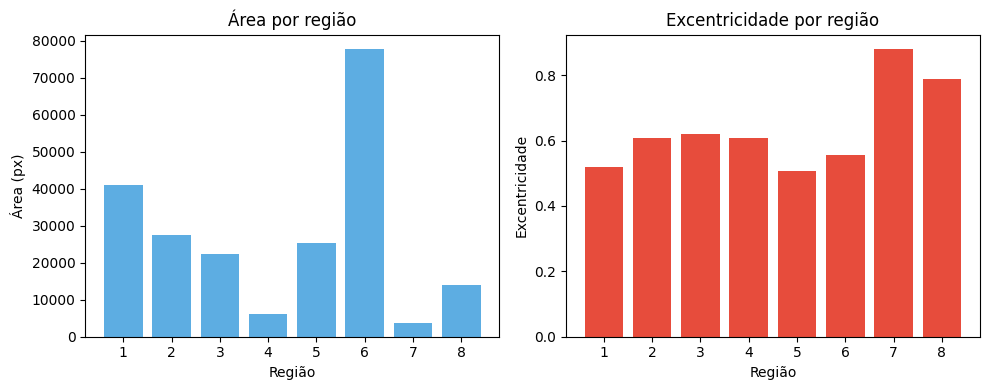

In [3]:
img = img_coins2
T = filters.threshold_otsu(img)
img_bin = (img > T).astype(np.uint8)

# limpeza morfológica
img_clean = morphology.remove_small_holes(morphology.remove_small_objects(img_bin.astype(bool), 3500)).astype(np.uint8)

# rotulagem
labels = measure.label(img_clean, connectivity=2)
num_regions = labels.max()

# coloração e overlay
colored = colorize_labels(labels)
overlay_img = overlay(img, labels > 0, alpha=0.4)

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].imshow(img, cmap='gray')
ax[0].set_title('Imagem original')
ax[0].axis('off')
ax[1].imshow(img_clean, cmap='gray_r')
ax[1].set_title('Imagem binarizada e limpa')
ax[1].axis('off')
ax[2].imshow(overlay_img)
ax[2].set_title(f'Regiões rotuladas — {num_regions} moedas')
ax[2].axis('off')
plt.tight_layout()
plt.show()

# métricas por região
props = measure.regionprops_table(
    labels,
    intensity_image=img,
    properties=('label', 'area', 'perimeter', 'centroid', 'eccentricity', 'solidity', 'mean_intensity')
)

import pandas as pd
df = pd.DataFrame(props)
display(df.round(2))

# gráfico resumo
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].bar(df['label'], df['area'], color='#5DADE2')
ax[0].set_title('Área por região')
ax[0].set_xlabel('Região')
ax[0].set_ylabel('Área (px)')
ax[1].bar(df['label'], df['eccentricity'], color='#E74C3C')
ax[1].set_title('Excentricidade por região')
ax[1].set_xlabel('Região')
ax[1].set_ylabel('Excentricidade')
plt.tight_layout()
plt.show()

## 4.4.4. Calcular centroides manualmente

Esta célula introduz uma **análise geométrica detalhada das regiões rotuladas**, focando-se em três medidas fundamentais:  
**centroide**, **caixa delimitadora (bounding box)** e **orientação principal**.

**Descrição sequencial do código**  
1) Calculam-se manualmente os **centroides** e **bounding boxes** de cada região:  
   - O centroide $(c_x, c_y)$ é a média das coordenadas $(x, y)$ dos píxeis pertencentes à região.  
   - A caixa delimitadora é definida pelos extremos mínimo e máximo de $x$ e $y$, ou seja,  
     $$x_{min}, x_{max}, y_{min}, y_{max}$$  
   Estes valores são guardados em dois dicionários (`centroids` e `bboxes`), indexados pelo número da região.

2) As **caixas delimitadoras** são desenhadas sobre uma versão RGB da imagem (`img_bb`),  
com cores geradas de forma pseudoaleatória a partir do índice da região.  
O resultado é apresentado com `show()`, evidenciando graficamente a extensão de cada forma.

3) Em seguida, é calculada a **orientação principal** de cada região com base nos **momentos de segunda ordem**:  
   - $\mu_{20}$, $\mu_{02}$ e $\mu_{11}$ são momentos centrados que descrevem a distribuição de massa em torno do centroide;  
   - o ângulo $\theta$ do eixo principal é obtido por:  
     $$\theta = \frac{1}{2}\arctan\left(\frac{2\mu_{11}}{\mu_{20} - \mu_{02}}\right)$$  
   Este ângulo é medido em radianos, com 0° correspondente ao eixo horizontal.

4) Num gráfico final, sobre a imagem original, são traçados:  
   - os **centroides** (pontos amarelos);  
   - os **vetores de orientação** (setas vermelhas) indicando a direção principal;  
   - os **rótulos numéricos** (texto amarelo) para identificação de cada região.

5) Por fim, utiliza-se `measure.regionprops(labels_shapes)` para validar os resultados obtidos manualmente.  
Para cada região, são impressos o centroide, a bounding box e a orientação calculados pela biblioteca,  
confirmando a coerência entre os métodos manual e automático.

**Interpretação e observações**  
- A orientação e a bounding box são **descritores geométricos de segunda ordem**, essenciais para análises de forma.  
- O vetor de orientação permite inferir **direções predominantes** e é frequentemente usado em tarefas de reconhecimento de objetos e análise de textura.  
- A comparação entre o cálculo manual e `regionprops` reforça a compreensão do funcionamento interno da biblioteca scikit-image.  
- Este tipo de análise é particularmente útil em contextos como **inspeção de peças industriais**, **análise de fibras**, ou **segmentação de células alongadas**.

Em síntese, a célula demonstra de forma clara e visual como extrair e representar **propriedades geométricas fundamentais** — posição, extensão e orientação — das regiões segmentadas numa imagem binária.

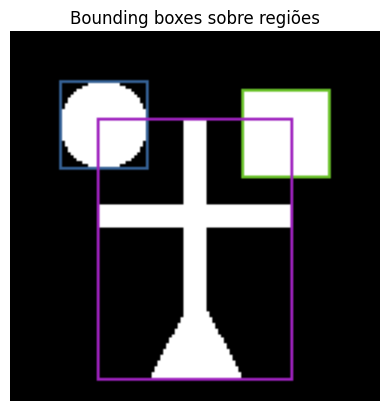

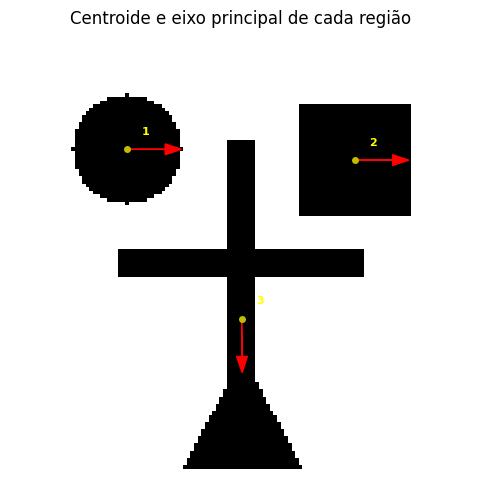

Região 1:
  Centroide: [32. 32.]
  Bounding box: (17, 17, 48, 48)
  Orientação (radianos): 0.785

Região 2:
  Centroide: [35. 95.]
  Bounding box: (20, 80, 51, 111)
  Orientação (radianos): 0.785

Região 3:
  Centroide: [78.89 63.66]
  Bounding box: (30, 30, 121, 98)
  Orientação (radianos): 0.011



In [4]:
centroids = {}
bboxes = {}
for lab in range(1, labels_shapes.max() + 1):
    coords = np.argwhere(labels_shapes == lab)
    if coords.size == 0:
        continue
    cy, cx = coords.mean(axis=0)
    centroids[lab] = (cx, cy)
    ys, xs = coords[:, 0], coords[:, 1]
    x_min, x_max = xs.min(), xs.max()
    y_min, y_max = ys.min(), ys.max()
    bboxes[lab] = (x_min, y_min, x_max, y_max)

img_bb = np.stack([img_multi*255]*3, axis=2).astype(np.uint8)
for idx, box in bboxes.items():
    x0, y0, x1, y1 = box
    color_box = (int((idx*53) % 256), int((idx*97) % 256), int((idx*149) % 256))
    cv2.rectangle(img_bb, (x0, y0), (x1, y1), color_box, 1)
show(img_bb, 'Bounding boxes sobre regiões')

orientations = {}
for lab, (cx, cy) in centroids.items():
    coords = np.argwhere(labels_shapes == lab)
    x = coords[:, 1] - cx
    y = coords[:, 0] - cy
    mu20 = np.sum(x**2)
    mu02 = np.sum(y**2)
    mu11 = np.sum(x * y)
    angle = 0.5 * np.arctan2(2 * mu11, (mu20 - mu02))
    orientations[lab] = angle

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img_multi, cmap='gray_r')
for lab, (cx, cy) in centroids.items():
    angle = orientations[lab]
    dx = 15 * np.cos(angle)
    dy = 15 * np.sin(angle)
    ax.plot(cx, cy, 'yo', markersize=4)
    ax.arrow(cx, cy, dx, dy, head_width=3, color='red', length_includes_head=True)
    ax.text(cx + 4, cy - 4, str(lab), color='yellow', fontsize=8, weight='bold')
ax.set_title('Centroide e eixo principal de cada região')
ax.axis('off')
plt.show()

props = measure.regionprops(labels_shapes)
for p in props:
    print(f"Região {p.label}:")
    print(f"  Centroide: {np.round(p.centroid, 2)}")
    print(f"  Bounding box: {p.bbox}")
    print(f"  Orientação (radianos): {np.round(p.orientation, 3)}")
    print()

## 4.4.5. Contornos e Chain Codes

Esta célula introduz a **cadeia de códigos de Freeman (Freeman Chain Code)** — um método clássico para descrever **o contorno de um objeto** de forma compacta e direcional.  
É aplicada aqui à maior região identificada em `labels_shapes`, permitindo observar tanto a **sequência direcional** do contorno como a **distribuição das direções predominantes**.

**Descrição sequencial do código**  
1) O primeiro passo é **selecionar a maior região conectada** com base na contagem de píxeis (`np.argmax(counts)`).  
   A máscara resultante (`mask`) representa unicamente essa forma, isolando-a do restante fundo.

2) O contorno é extraído com `cv2.findContours`, que devolve as coordenadas dos pontos fronteira.  
   Como o OpenCV usa a convenção (x, y), e as operações matriciais do NumPy seguem (linha, coluna), inverte-se a ordem para garantir coerência:  
   $$\text{contour} = contour[:, ::-1]$$

3) Define-se o **conjunto das 8 direções de vizinhança** (Freeman 8) na convenção matricial:  
   $$
   \text{dirs} = [(-1,0), (-1,1), (0,1), (1,1), (1,0), (1,-1), (0,-1), (-1,-1)]
   $$  
   Cada direção é associada a um índice de 0 a 7, correspondente a um movimento N, NE, E, SE, S, SW, W ou NW.

4) A **cadeia de direções** é construída percorrendo o contorno ponto a ponto e comparando o deslocamento $(\Delta y, \Delta x)$ com cada direção possível.  
   O resultado é um vetor `chain` que representa o contorno como uma sequência discreta de movimentos direcionais — uma **assinatura geométrica invariante à translação**.

5) A primeira visualização apresenta o **contorno reconstruído** (linha amarela) sobre a máscara binária.  
   A segunda figura mostra um **mapa vetorial colorido** das direções, onde cada seta representa uma direção de movimento segundo o código de Freeman (0–7), colorida de acordo com a sua orientação (de vermelho a azul).

6) Em seguida, gera-se um **histograma das direções** — uma forma de análise estatística do contorno.  
   Cada barra indica quantas vezes uma determinada direção ocorre ao longo da fronteira.  
   Direções predominantes (por exemplo, E e W em formas horizontais) tornam-se imediatamente visíveis.

**Interpretação e observações**  
- O código de Freeman é uma representação eficiente do **perímetro de formas binárias**, amplamente usada em compressão, reconhecimento de padrões e extração de descritores de forma.  
- A sua invariância à translação permite comparar contornos independentemente da posição, embora rotações exijam normalização adicional.  
- O histograma direcional serve como um **descritor global de orientação**, captando tendências estruturais do objeto.  
- A abordagem pode ser estendida para cálculos como **comprimento do contorno**, **complexidade direcional**, ou **simetria angular**.

Em resumo, esta célula demonstra de forma visual e quantitativa como a **cadeia de códigos de Freeman** traduz a geometria de um contorno em informação simbólica, ligando processamento de imagem a **análise de forma e reconhecimento estrutural**.

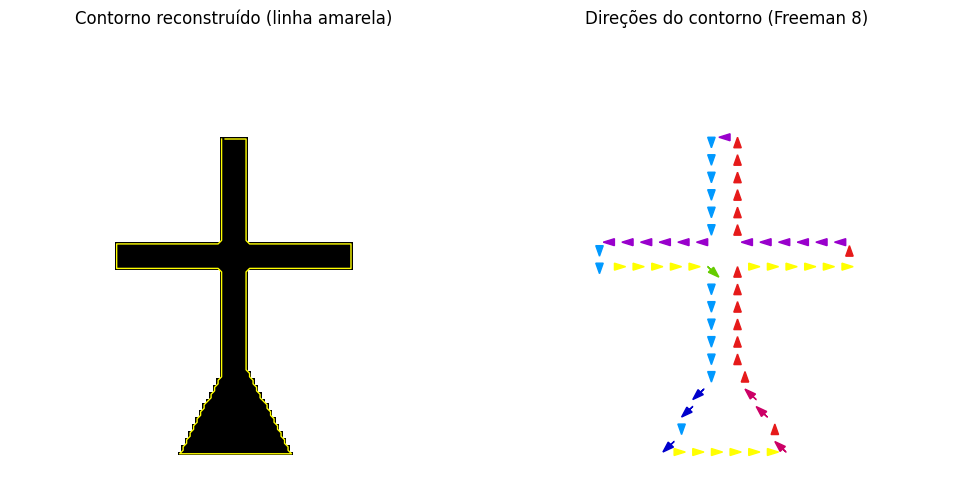

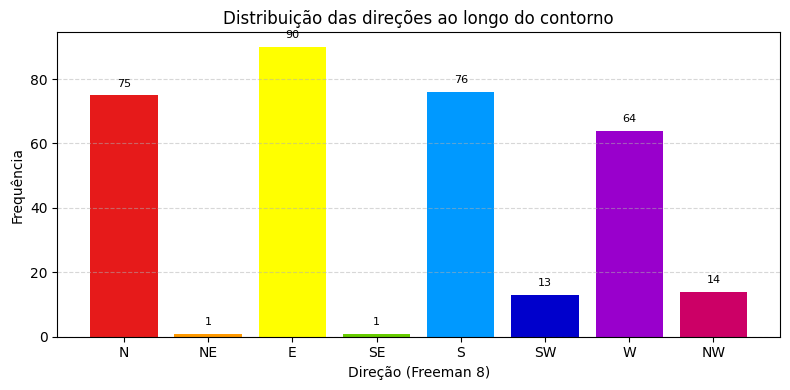

In [5]:
# Selecionar a maior região
labs, counts = np.unique(labels_shapes, return_counts=True)
labs, counts = labs[1:], counts[1:]
lab_sel = labs[np.argmax(counts)]
mask = (labels_shapes == lab_sel).astype(np.uint8)

# Extrair contorno (cv2 findContours usa ordem (x,y))
contour = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)[0][0][:, 0, :]
contour = contour[:, ::-1]  # inverter ordem para (linha,coluna)

# Direções de Freeman (0–7) em convenção matriz (linha,coluna)
dirs = [(-1, 0), (-1, 1), (0, 1), (1, 1), (1, 0), (1, -1), (0, -1), (-1, -1)]
dir_map = {d: i for i, d in enumerate(dirs)}


# 3. Calcular cadeia de direções
chain = []
for i in range(len(contour) - 1):
    dy = contour[i+1, 0] - contour[i, 0]
    dx = contour[i+1, 1] - contour[i, 1]
    for k, (ddy, ddx) in enumerate(dirs):
        if (dy, dx) == (ddy, ddx):
            chain.append(k)
            break
chain = np.array(chain)

colors = np.array([
    [0.9, 0.1, 0.1],   # N
    [1.0, 0.6, 0.0],   # NE
    [1.0, 1.0, 0.0],   # E
    [0.4, 0.8, 0.0],   # SE
    [0.0, 0.6, 1.0],   # S
    [0.0, 0.0, 0.8],   # SW
    [0.6, 0.0, 0.8],   # W
    [0.8, 0.0, 0.4],   # NW
])

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(mask, cmap='gray_r')
y, x = contour.T
axes[0].plot(x, y, color='yellow', linewidth=1)
axes[0].set_title('Contorno reconstruído (linha amarela)')
axes[0].axis('off')

axes[1].set_facecolor('white')
axes[1].set_xlim(0, mask.shape[1])
axes[1].set_ylim(mask.shape[0], 0)
axes[1].set_title('Direções do contorno (Freeman 8)')
axes[1].axis('off')

step = max(1, len(contour)//60)
for i in range(0, len(contour)-1, step):
    y, x = contour[i]
    d = chain[i]
    dy, dx = dirs[d]
    color = colors[d]
    axes[1].arrow(x, y, dx*3, dy*3, color=color, head_width=2, length_includes_head=True)

plt.tight_layout()
plt.show()

labels = np.arange(8)
counts, _ = np.histogram(chain, bins=np.arange(9)-0.5)
fig, ax = plt.subplots(figsize=(8,4))
bars = ax.bar(labels, counts, color=colors)

ax.set_xticks(labels)
ax.set_xticklabels(["N", "NE", "E", "SE", "S", "SW", "W", "NW"])

ax.set_xlabel('Direção (Freeman 8)')
ax.set_ylabel('Frequência')
ax.set_title('Distribuição das direções ao longo do contorno')
ax.grid(True, axis='y', linestyle='--', alpha=0.5)

for rect, c in zip(bars, counts):
    ax.text(rect.get_x() + rect.get_width()/2, c + 2, f'{int(c)}',
            ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

## 4.4.6. Aproximação poligonal

Esta célula implementa e demonstra o **método de Split and Merge** (dividir e unir) para **simplificação poligonal de contornos**, aplicando-o a uma forma ondulada sintética e analisando o compromisso entre **fidelidade geométrica** e **complexidade do modelo**.

**Descrição sequencial do código**  
1) A função `trace_contour(binary)` extrai o **contorno** de uma forma binária usando `cv2.findContours`, retornando uma lista ordenada de coordenadas $(y, x)$ que descrevem a fronteira.

2) A função recursiva `split_merge_contour(points, tol)` executa a **simplificação poligonal** com base na distância perpendicular máxima entre o contorno e a linha que une os seus extremos:  
   - Calcula o vetor de linha entre o primeiro e último ponto.  
   - Mede a distância máxima de cada ponto intermédio a essa linha.  
   - Se a distância máxima for maior que a **tolerância `tol`**, o algoritmo **divide** o segmento nesse ponto e aplica o processo recursivamente às duas metades.  
   - Caso contrário, substitui toda a sequência por uma **linha reta** entre os extremos.  
   Este procedimento reduz o número de vértices, preservando apenas os pontos relevantes à forma global.

3) É criada uma **forma ondulada sintética** com variação radial definida por:  
   $$r(\theta) = 80 + 10\sin(3\theta) + 6\cos(2\theta)$$  
   e desenhada com `cv2.fillPoly`. Esta figura fornece um contorno contínuo e irregular, ideal para testar o comportamento do algoritmo.

4) Para diferentes valores de tolerância (`tol = 1, 3, 6, 12`), o contorno é aproximado e visualizado:  
   - a linha **amarela** representa o contorno original;  
   - a linha **vermelha tracejada** mostra a versão simplificada.  
   O título de cada gráfico indica o número de vértices resultantes, revelando como o aumento da tolerância elimina detalhes progressivamente.

5) Define-se uma **métrica de erro médio** (`error_metric`) como a média das distâncias mínimas entre cada ponto do contorno original e o conjunto de vértices simplificados.  
   Este valor quantifica a **perda de fidelidade** introduzida pela simplificação.

6) Por fim, os gráficos de **avaliação quantitativa** apresentam:  
   - número de vértices (em azul) — medindo a **complexidade do contorno**;  
   - erro médio (em vermelho) — medindo a **deformação geométrica**.  
   Observa-se uma **relação inversa**: quanto maior a tolerância, menor o número de vértices e maior o erro.

**Interpretação e observações**  
- O método Split and Merge é uma forma intuitiva e eficiente de **reduzir dados espaciais** preservando a estrutura principal de uma fronteira.  
- É amplamente utilizado em **análise de formas**, **compressão vetorial** e **processamento de trajetórias GPS**.  
- A escolha de `tol` controla o equilíbrio entre **detalhe e simplicidade**:  
  tolerâncias pequenas mantêm o contorno quase intacto, enquanto valores grandes geram formas esquemáticas.  
- A métrica de erro ajuda a quantificar objetivamente a degradação introduzida, permitindo calibração automática.

Em suma, esta célula mostra como o algoritmo **Split and Merge** fornece uma representação poligonal controlada e escalável de contornos complexos, essencial para aplicações em **reconhecimento de objetos, vetorização e modelação geométrica**.

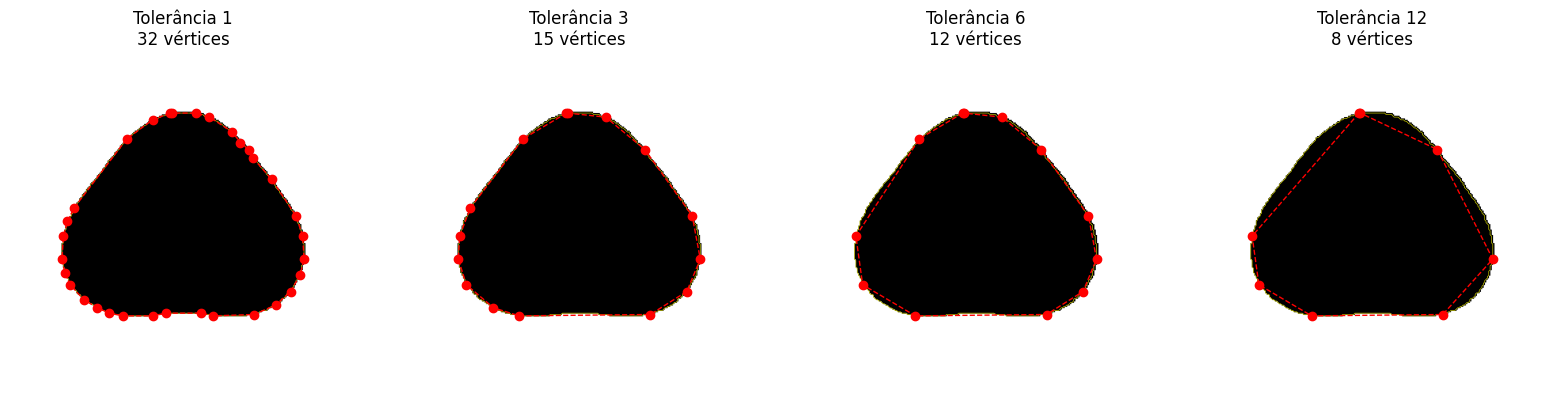

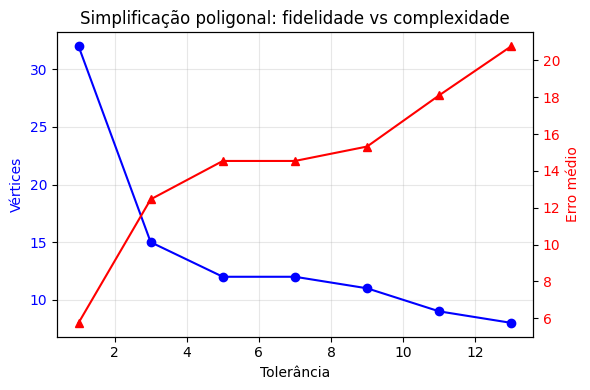

In [6]:
def trace_contour(binary):
    contours, _ = cv2.findContours(binary.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    pts = contours[0][:, 0, :]
    return [(y, x) for (x, y) in pts]

def split_merge_contour(points, tol):
    if len(points) < 3:
        return [points[0], points[-1]]
    first, last = np.array(points[0]), np.array(points[-1])
    line_vec = last - first
    line_len = np.linalg.norm(line_vec)
    if line_len == 0:
        return [points[0], points[-1]]
    max_dist, idx_max = -1, 0
    for idx, p in enumerate(points[1:-1], start=1):
        vec = np.array(p) - first
        area = np.abs(np.cross(line_vec, vec))
        dist = area / line_len
        if dist > max_dist:
            max_dist, idx_max = dist, idx
    if max_dist > tol:
        left = split_merge_contour(points[:idx_max+1], tol)
        right = split_merge_contour(points[idx_max:], tol)
        return left[:-1] + right
    else:
        return [points[0], points[-1]]

size = 256
Y, X = np.ogrid[:size, :size]
theta = np.linspace(0, 2*np.pi, 300)
r = 80 + 10*np.sin(3*theta) + 6*np.cos(2*theta)
x = (size/2 + r*np.cos(theta)).astype(int)
y = (size/2 + r*np.sin(theta)).astype(int)
img_wave = np.zeros((size, size), dtype=np.uint8)
cv2.fillPoly(img_wave, [np.stack([x, y], axis=1)], 1)

contour_coords = trace_contour(img_wave)

tolerances = [1, 3, 6, 12]
fig, axs = plt.subplots(1, len(tolerances), figsize=(4*len(tolerances), 4))
for ax, tol in zip(axs, tolerances):
    approx = split_merge_contour(contour_coords, tol)
    ax.imshow(img_wave, cmap='gray_r')
    ax.plot([p[1] for p in contour_coords], [p[0] for p in contour_coords], 'y-', lw=0.5)
    ax.plot([p[1] for p in approx], [p[0] for p in approx], 'r--o', lw=1)
    ax.set_title(f'Tolerância {tol}\n{len(approx)} vértices')
    ax.axis('off')
plt.tight_layout()
plt.show()

def error_metric(original, approx):
    err = 0
    for p in original:
        dists = [np.linalg.norm(np.array(p) - np.array(q)) for q in approx]
        err += min(dists)
    return err / len(original)

tols = np.arange(1, 14, 2)
verts, errs = [], []
for t in tols:
    ap = split_merge_contour(contour_coords, t)
    verts.append(len(ap))
    errs.append(error_metric(contour_coords, ap))

fig, ax1 = plt.subplots(figsize=(6,4))
ax1.plot(tols, verts, 'bo-', label='Nº de vértices')
ax1.set_xlabel('Tolerância')
ax1.set_ylabel('Vértices', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax2 = ax1.twinx()
ax2.plot(tols, errs, 'r^-', label='Erro médio')
ax2.set_ylabel('Erro médio', color='r')
ax2.tick_params(axis='y', labelcolor='r')
ax1.set_title('Simplificação poligonal: fidelidade vs complexidade')
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Para ilustrar o efeito da tolerância, aplicamos a função de aproximação a valores crescentes e desenhamos os vértices resultantes. À medida que a tolerância aumenta, menos pontos são necessários para representar o contorno, mas a precisão diminui.

## 4.4.7. Implementar Hull Convexo manual (algoritmo de Andrew)

Esta célula introduz o conceito de **hull convexo** (ou **envolvente convexa**) e da sua métrica associada, a **solidez**, aplicando-os à análise de uma forma binarizada derivada de uma imagem real.  
O objetivo é quantificar o grau de **concavidade** e identificar visualmente as regiões onde a forma se desvia da convexidade ideal.

**Descrição sequencial do código**  
1) A imagem `img_rock` é redimensionada para 256×256 píxeis e binarizada com um limiar fixo (`cv2.threshold`).  
   Caso o fundo ocupe mais de metade da imagem, o binário é invertido de modo a que o **objeto seja branco (1)** e o fundo preto (0).

2) Para eliminar ruído e garantir que se trabalha apenas com o **maior componente conexo**,  
   a imagem é rotulada com `cv2.connectedComponents`, e seleciona-se a região com mais píxeis (`largest_label`).

3) O **contorno da região principal** é obtido com `cv2.findContours`.  
   A partir dele, calcula-se o **hull convexo** com `cv2.convexHull`,  
   que corresponde à menor forma convexa que contém completamente o objeto — análogo a uma película elástica que se estica em torno da figura.

4) O hull é desenhado sobre a imagem original e, para realçar as **regiões côncavas**,  
   constrói-se uma máscara do hull (`hull_mask`) e subtrai-se a forma original (`img_clean`).  
   As áreas restantes (em vermelho) representam os **defeitos convexos**, ou seja, zonas onde a forma se afasta da convexidade.

5) Calcula-se a **solidez** da forma, uma métrica adimensional definida como:  
   $$
   \text{Solidez} = \frac{A_{\text{região}}}{A_{\text{hull}}}
   $$
   onde $A_{\text{região}}$ é a área original e $A_{\text{hull}}$ a área da envolvente convexa.  
   Valores próximos de 1 indicam uma forma quase convexa; valores mais baixos indicam concavidades pronunciadas.

6) Por fim, são apresentados gráficos de **comparação de áreas** (região vs hull)  
   e o valor de solidez é exibido diretamente no gráfico para interpretação imediata.

**Interpretação e observações**  
- O **hull convexo** é uma ferramenta fundamental na morfometria, análise de partículas e reconhecimento de formas.  
  Permite medir **regularidade**, **compactação** e **grau de concavidade** de um objeto.  
- A **solidez** é um descritor simples mas robusto — útil para distinguir, por exemplo,  
  pedras inteiras de fragmentos, folhas inteiras de folhas recortadas, ou bolhas regulares de bolhas deformadas.  
- As áreas em vermelho visualizam claramente **onde e quanto a forma se desvia da convexidade**,  
  permitindo diagnósticos qualitativos complementares à métrica quantitativa.

Em resumo, esta célula demonstra como extrair e visualizar o **hull convexo** e a **solidez**,  
duas ferramentas clássicas e poderosas na **análise de forma e contorno**.

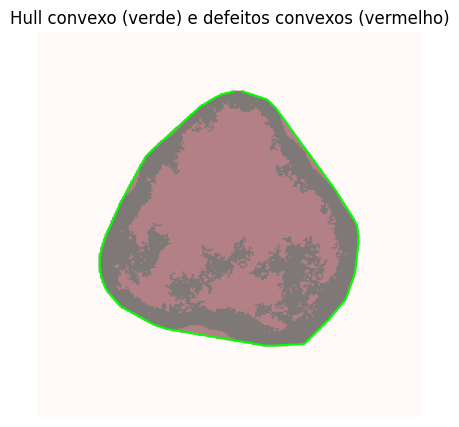

Solidez: 0.970


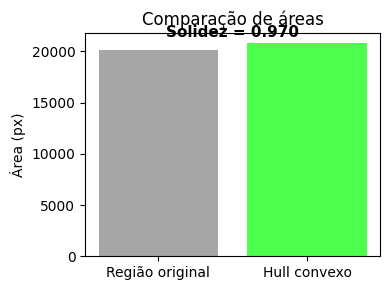

In [7]:
img_wave = cv2.resize(img_rock, (256, 256), interpolation=cv2.INTER_AREA)
_, img_wave_bin = cv2.threshold(img_wave, 127, 1, cv2.THRESH_BINARY)
# inverter se o fundo for maior que o objeto
if img_wave_bin.sum() > img_wave_bin.size / 2:
    img_wave_bin = 1 - img_wave_bin

num_labels, labels = cv2.connectedComponents(img_wave_bin.astype(np.uint8))
largest_label = 1 + np.argmax(np.bincount(labels.flat)[1:])
img_clean = (labels == largest_label).astype(np.uint8)

contours, _ = cv2.findContours(img_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cnt = contours[0]
hull = cv2.convexHull(cnt)

hull_mask = np.zeros_like(img_clean, dtype=np.uint8)
cv2.fillPoly(hull_mask, [hull], 1)
defects = hull_mask - img_clean
defects[defects < 0] = 0

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(img_clean, cmap='gray_r', origin='upper')
ax.plot(hull[:, 0, 0], hull[:, 0, 1], color='lime', lw=1.5)
ax.imshow(defects, cmap='Reds', alpha=0.5)
ax.set_title('Hull convexo (verde) e defeitos convexos (vermelho)')
ax.axis('off')
plt.show()

area_region = cv2.contourArea(cnt)
hull_area = cv2.contourArea(hull)
solidity = area_region / hull_area
print(f"Solidez: {solidity:.3f}")

areas = {'Região original': area_region, 'Hull convexo': hull_area}
fig, ax = plt.subplots(figsize=(4, 3))
bars = ax.bar(areas.keys(), areas.values(), color=['gray', 'lime'], alpha=0.7)
ax.set_title('Comparação de áreas')
ax.set_ylabel('Área (px)')
ax.text(0.5, max(areas.values()) * 1.03, f'Solidez = {solidity:.3f}', 
        ha='center', color='black', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


## 4.4.8. Descritores de Fronteira

Esta célula introduz a **análise de forma via transformada de Fourier** aplicada a contornos binários.  
O objetivo é representar o **perfil radial** de uma forma como uma **série de Fourier**, permitindo quantificar e reconstruir a geometria a partir de um número limitado de componentes harmónicos.

**Descrição sequencial do código**  
1) A função `fourier_shape_analysis()` começa por extrair o **contorno** da forma binária (`measure.find_contours`) e calcular o seu **centróide** $(c_x, c_y)$.  
   Cada ponto do contorno é descrito em coordenadas polares, com um ângulo $\theta$ e uma distância radial $r(\theta)$ em relação ao centróide:
   $$
   r(\theta) = \sqrt{(x - c_x)^2 + (y - c_y)^2}
   $$

2) Aplica-se a **Transformada Discreta de Fourier (DFT)** sobre $r(\theta)$ para obter os coeficientes complexos `coeffs`.  
   Estes coeficientes representam a forma como uma soma ponderada de senos e cossenos de diferentes frequências, isto é:
   $$
   r(\theta) \approx a_0 + \sum_{k=1}^{N} [a_k \cos(k\theta) + b_k \sin(k\theta)]
   $$

3) A **magnitude dos coeficientes** (gráfico superior direito) mostra quanta “energia” cada harmónico contribui para a forma — os primeiros coeficientes representam estruturas globais, os últimos captam detalhes e ruído.

4) A função `reconstruct_from_coeffs()` permite reconstruir aproximações sucessivas da forma a partir dos $N$ primeiros harmónicos.  
   Ao usar $N = 5, 10, 20$, observa-se como o aumento de termos produz reconstruções progressivamente mais detalhadas da função radial $r(\theta)$ (gráficos inferiores).

5) A execução da função é repetida para três formas simples: **quadrado**, **triângulo** e **círculo**,  
   permitindo comparar como as componentes de Fourier diferem entre formas com diferentes níveis de regularidade e simetria.

**Interpretação e observações**  
- O **círculo** possui um espectro dominado pela componente DC (frequência zero), já que $r(\theta)$ é quase constante.  
- O **triângulo** apresenta picos bem definidos nas baixas frequências, refletindo sua periodicidade angular.  
- O **quadrado** requer mais harmónicos para ser bem descrito, pois possui descontinuidades angulares abruptas (arestas e vértices).  
- O número de coeficientes necessários para uma boa reconstrução fornece uma **medida de complexidade da forma**.

Esta técnica, conhecida como **Fourier Descriptors**, é amplamente usada em **reconhecimento de formas**, **classificação morfológica** e **análise de fronteiras**,  
pois permite comparar objetos diferentes num espaço de características compacto e invariante à rotação, translação e escala (após normalização adequada).

Em suma, esta célula demonstra como a **Transformada de Fourier** pode ser aplicada à geometria — transformando formas espaciais em assinaturas espectrais que descrevem a sua **estrutura e regularidade**.

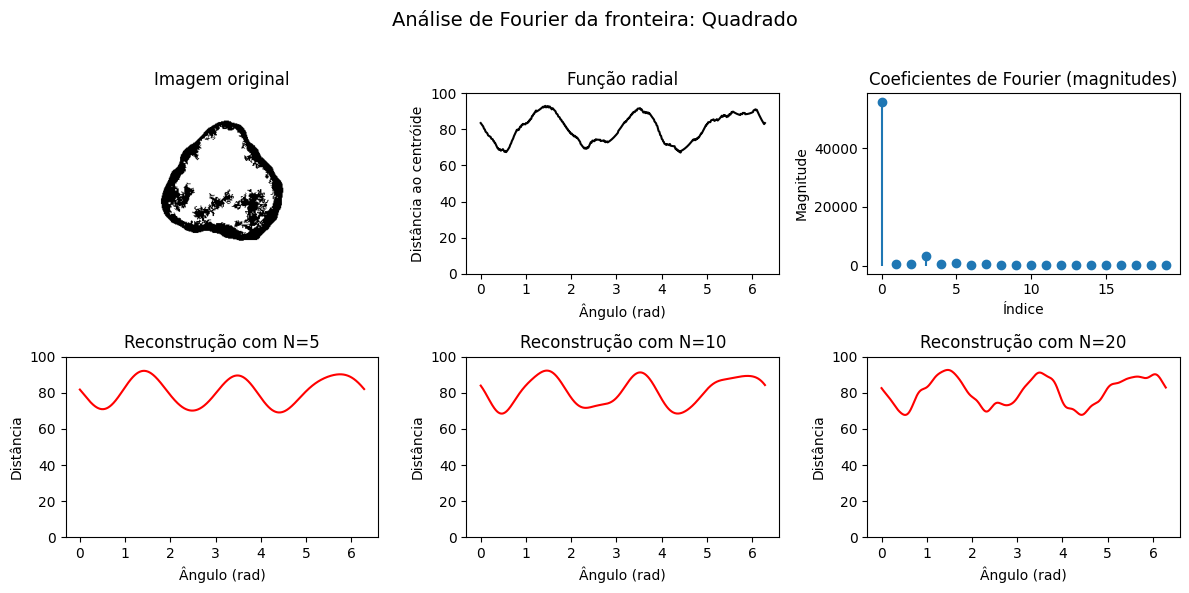

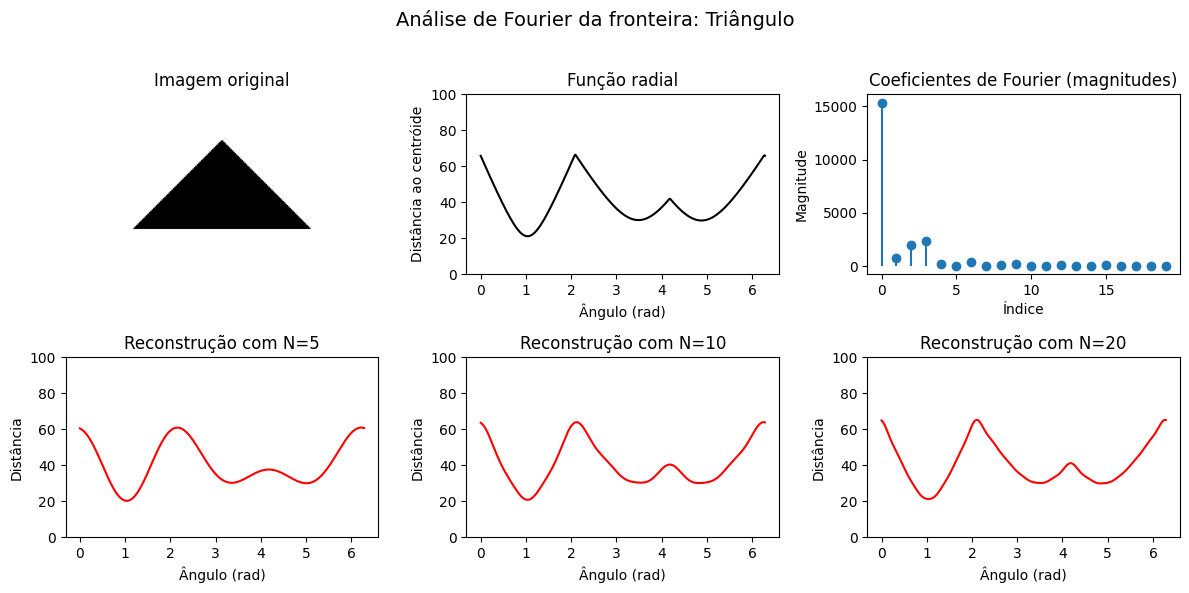

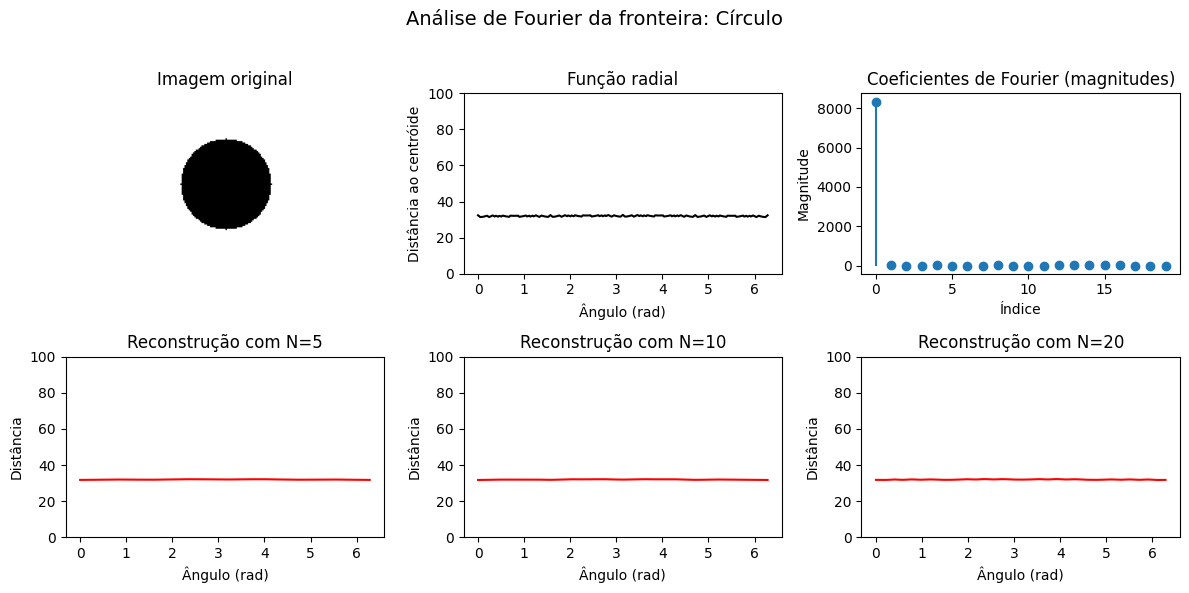

In [8]:
def fourier_shape_analysis(img_bin, name="Forma"):
    contour = measure.find_contours(img_bin, 0.5)[0]
    cy, cx = contour[:, 0].mean(), contour[:, 1].mean()
    angles = np.linspace(0, 2*np.pi, len(contour))
    r = np.sqrt((contour[:,1]-cx)**2 + (contour[:,0]-cy)**2)

    coeffs = np.fft.fft(r)
    mag = np.abs(coeffs)

    def reconstruct_from_coeffs(coeffs, N):
        tmp = np.zeros_like(coeffs)
        tmp[:N] = coeffs[:N]
        tmp[-N:] = coeffs[-N:]
        return np.fft.ifft(tmp).real

    recs = [reconstruct_from_coeffs(coeffs, N) for N in [5, 10, 20]]

    fig, axs = plt.subplots(2, 3, figsize=(12, 6))
    plt.suptitle(f'Análise de Fourier da fronteira: {name}', fontsize=14)

    axs[0,0].imshow(img_bin, cmap='gray_r', origin='upper')
    axs[0,0].set_title("Imagem original")
    axs[0,0].axis('off')

    axs[0,1].plot(angles, r, color='black')
    axs[0,1].set_ylim(0, 100)
    axs[0,1].set_title("Função radial")
    axs[0,1].set_xlabel("Ângulo (rad)")
    axs[0,1].set_ylabel("Distância ao centróide")

    axs[0,2].stem(mag[:20], basefmt=" ")
    #axs[0,2].set_ylim(0, 100)
    axs[0,2].set_title("Coeficientes de Fourier (magnitudes)")
    axs[0,2].set_xlabel("Índice")
    axs[0,2].set_ylabel("Magnitude")

    for ax, rec, N in zip(axs[1,:], recs, [5,10,20]):
        ax.plot(angles, rec, color='red')
        ax.set_ylim(0, 100)
        ax.set_title(f"Reconstrução com N={N}")
        ax.set_xlabel("Ângulo (rad)")
        ax.set_ylabel("Distância")

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


img1 = img_clean
img2 = img_triangle
img3 = img_circle

imgs = [(img1>0).astype(np.uint8), (img2>0).astype(np.uint8), (img3>0).astype(np.uint8)]
names = ["Quadrado", "Triângulo", "Círculo"]

for img, name in zip(imgs, names):
    fourier_shape_analysis(img, name)

## 4.4.9. Descritores de forma regionais

Esta célula apresenta os **momentos geométricos, centrais e normalizados** de regiões binárias, culminando nos **momentos invariantes de Hu**, amplamente usados na **descrição e reconhecimento de formas**.  
O objetivo é demonstrar como estes momentos sintetizam propriedades espaciais e geométricas de uma forma, de modo independente da sua posição, escala e rotação.

**Descrição sequencial do código**  
1) As funções `moments_region`, `central_moments` e `normalized_moments` calculam, respetivamente:
   - **Momentos geométricos** $m_{pq}$, definidos por  
     $$
     m_{pq} = \sum_x \sum_y x^p y^q f(x,y)
     $$
     onde $f(x,y)$ é a máscara binária da região.  
     Estes momentos codificam **área** ($m_{00}$), **centro de massa** e **distribuição de massa**.
   - **Momentos centrais** $\mu_{pq}$, que recentram a forma no seu centróide $(\bar{x}, \bar{y})$, tornando-os **invariantes à translação**:  
     $$
     \mu_{pq} = \sum_x \sum_y (x-\bar{x})^p (y-\bar{y})^q f(x,y)
     $$
   - **Momentos normalizados** $\eta_{pq}$, obtidos dividindo pelos poderes de $\mu_{00}$ para eliminar dependência de **escala**:
     $$
     \eta_{pq} = \frac{\mu_{pq}}{\mu_{00}^{(p+q)/2+1}}
     $$

2) A função `cv2.HuMoments()` calcula sete combinações não lineares de momentos normalizados — os **Momentos de Hu** — que são:
   - invariantes à **translação**, **rotação** e **escala**;
   - sensíveis à **estrutura global** da forma;
   - frequentemente usados como **descritores numéricos** em reconhecimento de objetos.

3) A célula aplica estas operações a três formas simples: **rocha**, **triângulo** e **círculo**.  
   Para cada uma:
   - imprime área e centróide (métricas geométricas básicas);
   - apresenta os momentos normalizados de 2ª ordem;
   - calcula e plota os sete momentos de Hu em escala logarítmica.

4) Na parte final, realiza-se um **teste de invariância**:  
   - uma versão ampliada e rodada do quadrado é comparada com a original;  
   - as diferenças no espaço logarítmico dos momentos de Hu são mostradas para confirmar a **estabilidade e invariância** dos descritores.

**Interpretação e observações**  
- Momentos de baixa ordem capturam propriedades globais como **área**, **posição** e **orientação**;  
  momentos de ordem mais elevada descrevem **detalhes locais e simetrias**.  
- O **círculo** apresenta momentos de Hu mais regulares e próximos de zero, refletindo a sua simetria perfeita.  
- O **triângulo** e a **rocha** exibem perfis distintos, com amplitudes desiguais e dispersão entre os sete momentos.  
- A pequena diferença entre os momentos do quadrado original e o quadrado rodado/redimensionado confirma empiricamente a **invariância transformacional**.

Em síntese, esta célula mostra como os **momentos regionais** evoluem até os **momentos invariantes de Hu**, oferecendo uma base sólida para **descrição quantitativa e classificação de formas** em imagens binárias.

=== Rocha ===
Área: 8867
Centróide (m10/m00, m01/m00): (130.3, 142.4)
μ20: 2.86397e-01, μ02: 2.28439e-01, μ11: 1.41848e-02
=== Triângulo ===
Área: 4032
Centróide (m10/m00, m01/m00): (63.5, 74.3)
μ20: 1.66646e-01, μ02: 5.55280e-02, μ11: 3.35668e-19
=== Círculo ===
Área: 3209
Centróide (m10/m00, m01/m00): (64.0, 64.0)
μ20: 7.95810e-02, μ02: 7.95810e-02, μ11: 0.00000e+00


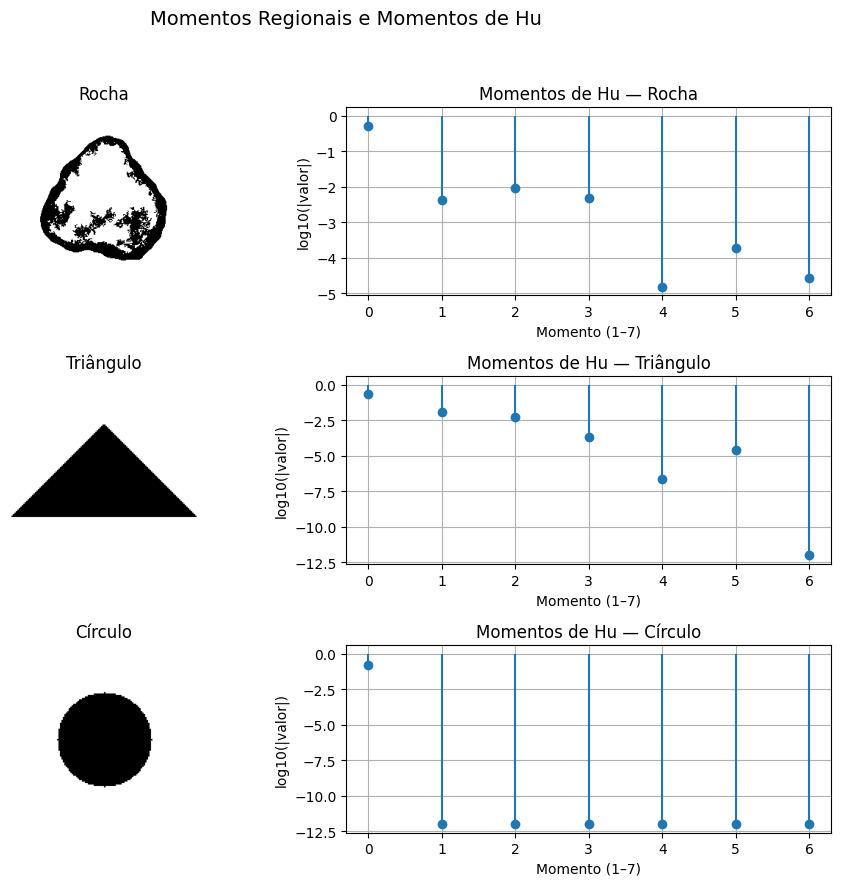


Teste de invariância (Quadrado original vs. ampliado+rodado):
Hu1: diferença log = 0.00
Hu2: diferença log = 0.00
Hu3: diferença log = 0.00
Hu4: diferença log = 0.00
Hu5: diferença log = 0.00
Hu6: diferença log = 0.00
Hu7: diferença log = 0.00


In [9]:
def moments_region(mask, order=2):
    coords = np.argwhere(mask)
    m = {}
    for p in range(order+1):
        for q in range(order+1-p):
            m[(p, q)] = np.sum((coords[:, 1] ** p) * (coords[:, 0] ** q))
    return m

def central_moments(mask, max_order=2):
    coords = np.argwhere(mask)
    cy, cx = coords.mean(axis=0)
    cms = {}
    for p in range(max_order+1):
        for q in range(max_order+1-p):
            cms[(p, q)] = np.sum(((coords[:, 1]-cx)**p) * ((coords[:, 0]-cy)**q))
    return cms

def normalized_moments(cms, gamma=1.0):
    mu00 = cms[(0, 0)]
    nms = {}
    for (p, q), val in cms.items():
        nms[(p, q)] = val / (mu00 ** ((p+q)/2 + gamma))
    return nms

def show_region(img, title):
    plt.imshow(img, cmap='gray_r')
    plt.title(title)
    plt.axis('off')

regions = [
    (img_clean, "Rocha"),
    (img_triangle, "Triângulo"),
    (img_circle, "Círculo")
]

fig, axs = plt.subplots(len(regions), 2, figsize=(10, 9))
plt.suptitle("Momentos Regionais e Momentos de Hu", fontsize=14)

hu_all = []

for i, (region, name) in enumerate(regions):
    mask = (region > 0).astype(np.uint8)

    # Momentos geométricos
    m0 = moments_region(mask)
    cms = central_moments(mask)
    nms = normalized_moments(cms)

    print(f"=== {name} ===")
    print(f"Área: {m0[(0,0)]:.0f}")
    print(f"Centróide (m10/m00, m01/m00): ({m0[(1,0)]/m0[(0,0)]:.1f}, {m0[(0,1)]/m0[(0,0)]:.1f})")
    print(f"μ20: {nms[(2,0)]:.5e}, μ02: {nms[(0,2)]:.5e}, μ11: {nms[(1,1)]:.5e}")

    # Momentos de Hu (invariantes)
    hu = cv2.HuMoments(cv2.moments(mask)).flatten()
    hu_all.append(np.log10(np.abs(hu) + 1e-12))

    # Visualização
    axs[i,0].imshow(mask, cmap='gray_r')
    axs[i,0].set_title(name)
    axs[i,0].axis('off')

    axs[i,1].stem(np.log10(np.abs(hu) + 1e-12), basefmt=" ")
    axs[i,1].set_title(f"Momentos de Hu — {name}")
    axs[i,1].set_xlabel("Momento (1–7)")
    axs[i,1].set_ylabel("log10(|valor|)")
    axs[i,1].grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

scaled = cv2.resize(img_square.astype(np.uint8), None, fx=1.5, fy=1.5, interpolation=cv2.INTER_NEAREST)
rot_scaled = scipy.ndimage.rotate(scaled, 30, reshape=False)
hu_original = cv2.HuMoments(cv2.moments(img_square.astype(np.uint8))).flatten()
hu_scaled = cv2.HuMoments(cv2.moments(rot_scaled.astype(np.uint8))).flatten()

print("\nTeste de invariância (Quadrado original vs. ampliado+rodado):")
for i, (h1, h2) in enumerate(zip(hu_original, hu_scaled), start=1):
    diff = abs(np.log10(abs(h1)+1e-12) - np.log10(abs(h2)+1e-12))
    print(f"Hu{i}: diferença log = {diff:.2f}")

## 4.4.10. Descritores topológicos

Esta célula aborda os **descritores topológicos** de uma forma binária — nomeadamente o **número de buracos** e o **número de Euler** — que capturam propriedades estruturais invariantes a transformações geométricas.  
O objetivo é distinguir formas com igual área e perímetro mas topologias diferentes, como a letra **A**, a letra **O** e um **anel**.

**Descrição sequencial do código**  
1) As funções `count_holes()` e `label_holes()` identificam **componentes de fundo** (em preto) que estão **totalmente cercadas** por píxeis do objeto.  
   - A imagem é invertida (`1 - mask`) e rotulada com `cv2.connectedComponents`.  
   - Qualquer componente de fundo que **não toque as bordas** é considerada um **buraco**.  
   - `label_holes()` devolve uma máscara binária desses buracos para visualização; `count_holes()` devolve o número total.

2) As funções `make_letter_A()` e `make_letter_O()` constroem padrões sintéticos binários:  
   - **A** tem uma forma com uma cavidade interna (triângulo interno da letra);  
   - **O** é um círculo oco, criado subtraindo um círculo menor a um maior.  
   - Um terceiro exemplo, o **anel**, é desenhado diretamente com `cv2.circle` e tem topologia idêntica à de “O”.

3) Para cada imagem, são calculados:
   - O **número de buracos** (via `count_holes()`);  
   - O **número de Euler**, obtido por `measure.regionprops(...).euler_number`, definido como:
     $$
     \chi = N_{\text{componentes}} - N_{\text{buracos}}
     $$
     Assim, um objeto sem buracos tem $\chi = 1$, um com um buraco tem $\chi = 0$, e um com dois buracos teria $\chi = -1$.

4) O resultado é apresentado sob a forma de **imagem RGB**:
   - o objeto é mostrado a **branco**,  
   - os buracos são realçados a **vermelho**,  
   - e o título indica o número de buracos e o número de Euler.

**Interpretação e observações**  
- A **letra A** contém uma única cavidade interna → **1 buraco, número de Euler = 0**.  
- A **letra O** e o **anel** também apresentam **1 buraco**, mas formas completamente diferentes → mesma topologia, geometria distinta.  
- Uma forma totalmente preenchida (sem buracos) teria **Euler = 1**, enquanto formas compostas ou múltiplas ilhas fariam aumentar $N_{\text{componentes}}$ e, portanto, $\chi$.

O **número de Euler** e o **número de buracos** são descritores fundamentais da **morfologia topológica** de um objeto —  
eles permanecem invariantes sob **translação, rotação, escala** e até pequenas **distorções contínuas**,  
servindo como base para análises estruturais, segmentação robusta e classificação de padrões.

Em suma, esta célula demonstra como medir **“o que está dentro”** de uma forma —  
uma perspetiva topológica que complementa as métricas métricas e geométricas vistas anteriormente.

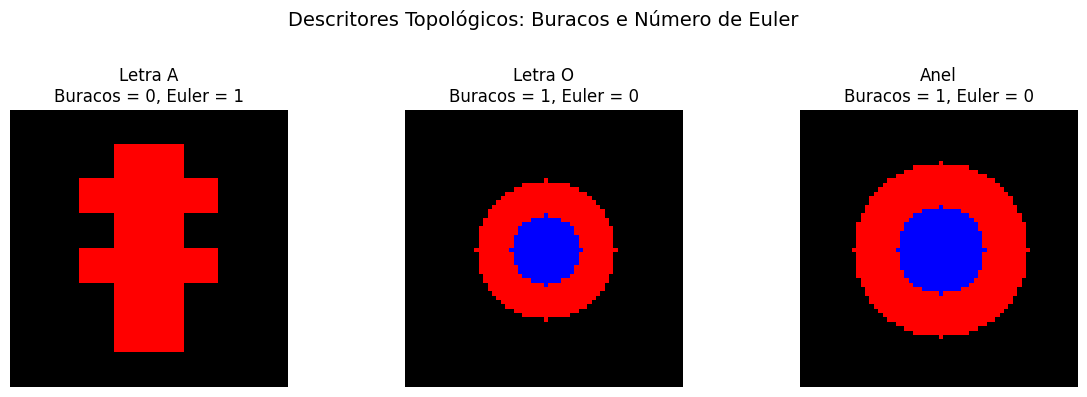

In [10]:
def count_holes(mask):
    inv = 1 - mask
    n_bg, labels_bg = cv2.connectedComponents(inv.astype(np.uint8))
    holes = 0
    for label in range(1, n_bg):  # ignora label 0 (fundo)
        component = (labels_bg == label)
        # se a componente não toca na borda, é um buraco
        if not (
            np.any(component[0, :]) or np.any(component[-1, :]) or 
            np.any(component[:, 0]) or np.any(component[:, -1])
        ):
            holes += 1
    return holes


def label_holes(mask):
    inv = 1 - mask
    n_bg, labels_bg = cv2.connectedComponents(inv.astype(np.uint8))
    holes = np.zeros_like(mask)
    for label in range(1, n_bg):
        component = (labels_bg == label)
        if not (
            np.any(component[0, :]) or np.any(component[-1, :]) or 
            np.any(component[:, 0]) or np.any(component[:, -1])
        ):
            holes[component] = 1
    return holes

def make_letter_A():
    img = np.zeros((64, 64), dtype=np.uint8)
    img[8:56, 24:40] = 1
    img[16:24, 16:48] = 1
    img[32:40, 16:48] = 1
    return img

def make_letter_O():
    img = np.zeros((64, 64), dtype=np.uint8)
    X, Y = np.ogrid[:64, :64]
    mask = (X-32)**2 + (Y-32)**2 <= 16**2
    img[mask] = 1
    hole = (X-32)**2 + (Y-32)**2 <= 8**2
    img[hole] = 0
    return img

A = make_letter_A()
O = make_letter_O()
ring = np.zeros((64, 64), dtype=np.uint8)
cv2.circle(ring, (32, 32), 20, 1, -1)
cv2.circle(ring, (32, 32), 10, 0, -1)

images_topo = [A, O, ring]
names = ["Letra A", "Letra O", "Anel"]

fig, axs = plt.subplots(1, len(images_topo), figsize=(12, 4))
plt.suptitle("Descritores Topológicos: Buracos e Número de Euler", fontsize=14)

for i, (img, name) in enumerate(zip(images_topo, names)):
    holes = label_holes(img)
    num_holes = count_holes(img)
    euler = measure.regionprops(img.astype(int))[0].euler_number

    overlay = np.dstack([
        img*255,
        np.zeros_like(img),
        holes*255
    ]).astype(np.uint8)

    axs[i].imshow(overlay, origin='upper')
    axs[i].set_title(f"{name}\nBuracos = {num_holes}, Euler = {euler}")
    axs[i].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

## 4.4.11. Descritores de textura

Esta célula introduz o conceito de **Matriz de Coocorrência de Níveis de Cinzento (GLCM)**,  
um dos descritores de textura mais clássicos da análise de imagens, e mostra como calcular e interpretar os seus principais **atributos estatísticos**:  
**contraste**, **homogeneidade**, **energia** e **entropia**.

**Descrição sequencial do código**  
1) Cria-se uma **imagem sintética 8×8** com três níveis discretos de intensidade (`0, 128, 255`), representando uma textura simplificada.  
   Essa matriz é mostrada a preto e branco, com transições visuais bem definidas entre tons.

2) Constrói-se manualmente a **GLCM** (Gray Level Co-occurrence Matrix) considerando a vizinhança **horizontal** $(r, c) \rightarrow (r, c+1)$:  
   - Cada célula $P(i,j)$ da GLCM conta quantas vezes um píxel de nível $i$ ocorre ao lado (à direita) de um píxel de nível $j$.  
   - Após a contagem, a matriz é **normalizada** para que a soma dos elementos seja 1, interpretando-a como uma **distribuição de probabilidade conjunta**.

   $$
   P(i,j) = \frac{\text{nº de ocorrências }(g(r,c)=i,\, g(r,c+1)=j)}{\sum_{i,j} \text{ocorrências}}
   $$

3) São então calculadas manualmente quatro **métricas texturais** clássicas:
   - **Contraste:** mede a variação local dos níveis de cinzento  
     $$
     \text{Contraste} = \sum_{i,j} (i-j)^2\,P(i,j)
     $$
     → alto para texturas com fortes transições tonais.
   - **Homogeneidade:** pondera a proximidade entre níveis de cinzento  
     $$
     \text{Homogeneidade} = \sum_{i,j} \frac{P(i,j)}{1 + |i-j|}
     $$
     → alto para regiões suaves e uniformes.
   - **Energia:** soma dos quadrados das probabilidades  
     $$
     \text{Energia} = \sum_{i,j} P(i,j)^2
     $$
     → mede a uniformidade da distribuição (máxima quando todos os pares têm probabilidade idêntica).
   - **Entropia:** mede o grau de desordem  
     $$
     \text{Entropia} = -\sum_{i,j} P(i,j)\log_2 P(i,j)
     $$
     → aumenta com a complexidade e aleatoriedade da textura.

4) Os mesmos valores são recalculados com `skimage.feature.graycomatrix` e `graycoprops`,  
confirmando a equivalência dos resultados.

5) Na segunda parte, a célula aplica esta metodologia a uma **imagem real de textura** (`img_textures2`):  
   - A imagem é dividida em **janelas 8×8**,  
   - e em cada uma calcula-se a GLCM e extrai-se o **contraste** e a **homogeneidade**.  
   - Os resultados são visualizados como **mapas locais** que destacam zonas de maior ou menor variabilidade.

**Interpretação e observações**  
- Regiões com **contraste elevado** correspondem a áreas texturadas, rugosas ou com bordos.  
- Regiões com **homogeneidade elevada** indicam superfícies lisas e uniformes.  
- A **energia** e a **entropia** refletem a regularidade ou desordem global da textura.  
- O uso de janelas móveis permite construir **mapas espaciais de textura**, úteis em segmentação

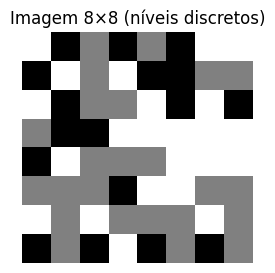

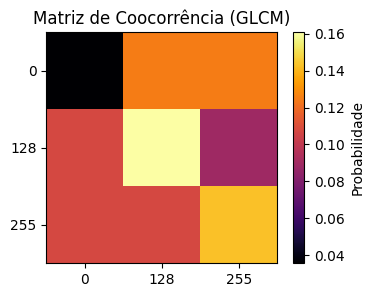

Contraste = 1.357
Homogeneidade = 0.631
Energia = 0.121
Entropia = 3.094

Via biblioteca:
Contraste = 22066.714
Homogeneidade = 0.339
Energia = 0.347


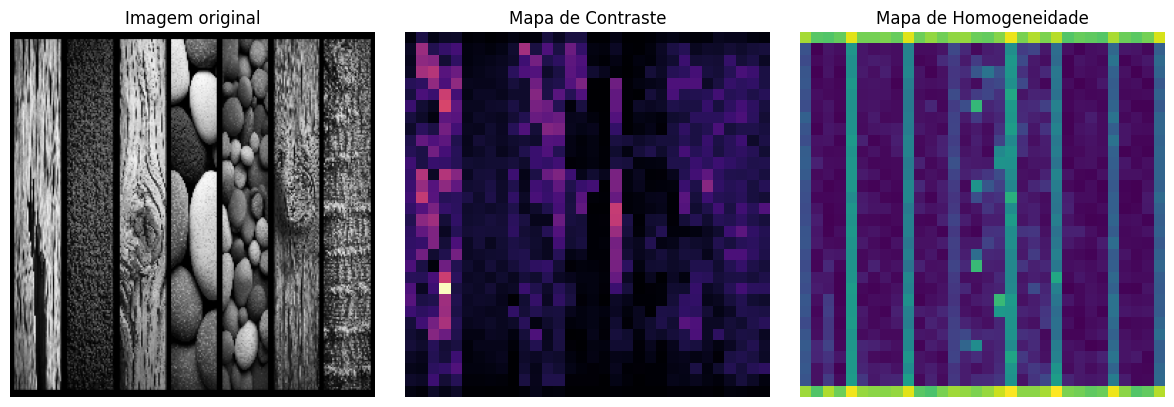

In [11]:
levels = [0, 128, 255]
glcm_img = np.random.choice(levels, size=(8, 8)).astype(np.uint8)

plt.figure(figsize=(3,3))
plt.imshow(glcm_img, cmap='gray', vmin=0, vmax=255)
plt.title('Imagem 8×8 (níveis discretos)')
plt.axis('off')
plt.show()

levels_sorted = np.array(sorted(levels))
level_indices = {v: i for i, v in enumerate(levels_sorted)}
glcm = np.zeros((len(levels_sorted), len(levels_sorted)), dtype=np.float64)

for r in range(glcm_img.shape[0]):
    for c in range(glcm_img.shape[1]-1):
        i = level_indices[glcm_img[r, c]]
        j = level_indices[glcm_img[r, c+1]]
        glcm[i, j] += 1

glcm /= glcm.sum()

plt.figure(figsize=(4,3))
plt.imshow(glcm, cmap='inferno', interpolation='nearest')
plt.colorbar(label='Probabilidade')
plt.xticks(range(3), levels_sorted)
plt.yticks(range(3), levels_sorted)
plt.title('Matriz de Coocorrência (GLCM)')
plt.show()

contrast = 0
homogeneity = 0
energy = 0
entropy = 0
for i in range(len(levels_sorted)):
    for j in range(len(levels_sorted)):
        p = glcm[i, j]
        contrast += (i - j)**2 * p
        homogeneity += p / (1 + abs(i - j))
        energy += p**2
        if p > 0:
            entropy -= p * np.log2(p)

print(f"Contraste = {contrast:.3f}")
print(f"Homogeneidade = {homogeneity:.3f}")
print(f"Energia = {energy:.3f}")
print(f"Entropia = {entropy:.3f}")

# Comparação com scikit-image
glcm_lib = graycomatrix(glcm_img, distances=[1], angles=[0],
                        levels=256, symmetric=True, normed=True)
contrast_lib = graycoprops(glcm_lib, 'contrast')[0,0]
homogeneity_lib = graycoprops(glcm_lib, 'homogeneity')[0,0]
energy_lib = graycoprops(glcm_lib, 'energy')[0,0]

print("\nVia biblioteca:")
print(f"Contraste = {contrast_lib:.3f}")
print(f"Homogeneidade = {homogeneity_lib:.3f}")
print(f"Energia = {energy_lib:.3f}")

img = img_textures2
img = cv2.resize(img, (256, 256))

window = 8
h, w = img.shape
map_contrast = np.zeros((h // window, w // window))
map_homog = np.zeros_like(map_contrast)

for i in range(0, h-window+1, window):
    for j in range(0, w-window+1, window):
        patch = img[i:i+window, j:j+window]
        g = graycomatrix(patch, distances=[1], angles=[0],
                         levels=256, symmetric=True, normed=True)
        map_contrast[i//window, j//window] = graycoprops(g, 'contrast')[0,0]
        map_homog[i//window, j//window] = graycoprops(g, 'homogeneity')[0,0]

fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].imshow(img, cmap='gray')
axs[0].set_title('Imagem original')
axs[1].imshow(map_contrast, cmap='magma')
axs[1].set_title('Mapa de Contraste')
axs[2].imshow(map_homog, cmap='viridis')
axs[2].set_title('Mapa de Homogeneidade')
for ax in axs: ax.axis('off')
plt.tight_layout()
plt.show()

## 4.4.12. Combinação de descritores e análise comparativa

Esta célula introduz a **análise quantitativa de regiões** — uma síntese de métricas geométricas, topológicas e estatísticas extraídas de cada forma rotulada — e demonstra como usar **Análise de Componentes Principais (PCA)** para representar relações entre essas regiões num espaço reduzido.

**Descrição sequencial do código**  
1) Visualiza-se a imagem com as **regiões rotuladas**, usando cores distintas e anotações `R1`, `R2`, etc., posicionadas nos respetivos centróides.

2) A função `region_descriptors_basic()` calcula um conjunto de **descritores morfológicos** para cada região:
   - **Área** — número total de píxeis pertencentes à região.  
   - **Perímetro** — comprimento aproximado da fronteira (usando `region.perimeter`).  
   - **Circularidade** — mede quão próxima a forma está de um círculo:  
     $$
     C = \frac{4 \pi \, A}{P^2}
     $$
     valores próximos de 1 indicam formas quase circulares.  
   - **Elongação** — razão entre o lado menor e o maior da *bounding box*, variando entre 0 (muito alongado) e 1 (isotrópico).  
   - **Solidez** — razão entre a área da região e a área do seu **hull convexo**, útil para medir concavidades e irregularidades:
     $$
     S = \frac{A}{A_\text{hull}}
     $$

   O resultado é organizado num **DataFrame**, permitindo comparação tabular e formatação com três casas decimais.

3) Para explorar relações entre descritores, aplica-se uma **PCA (Principal Component Analysis)** sobre as variáveis normalizadas (`X_std`), reduzindo as cinco dimensões originais para duas componentes ortogonais.  
   - A PCA transforma as variáveis correlacionadas em novas dimensões que maximizam a variância explicada;  
   - facilita a **visualização da semelhança estrutural** entre as regiões.

4) O gráfico de dispersão mostra cada região no plano das duas primeiras componentes principais.  
   - Regiões próximas no gráfico têm **descritores morfológicos semelhantes**.  
   - A direção e dispersão dos pontos indicam os **padrões dominantes de variação** — por exemplo, aumento de área ou redução de circularidade.

**Interpretação e observações**  
- As métricas **Área** e **Perímetro** tendem a ser correlacionadas, influenciando a primeira componente principal.  
- **Circularidade** e **Elongação** contribuem fortemente para distinguir formas compactas de formas lineares.  
- A **Solidez** permite diferenciar regiões regulares de regiões com bordas recortadas ou concavidades internas.  
- O mapa PCA serve, assim, como um **espaço morfológico reduzido**, no qual as formas se agrupam por semelhança estrutural — uma ferramenta poderosa para análise exploratória e classificação baseada em forma.

Em suma, esta célula combina **descritores regionais clássicos** com uma **representação estatística moderna (PCA)**, mostrando como traduzir propriedades visuais em relações quantitativas e comparáveis entre objetos segmentados.

,Região,Área,Perímetro,Circularidade,Elongação,Solidez
0,1,709,98.912,0.911,1.000,0.957
1,2,961,120.000,0.839,1.000,1.000
2,3,1512,346.598,0.158,0.747,0.351


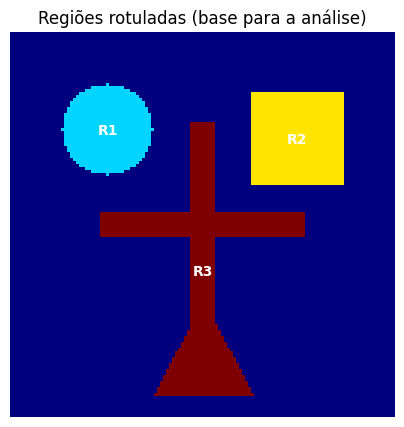

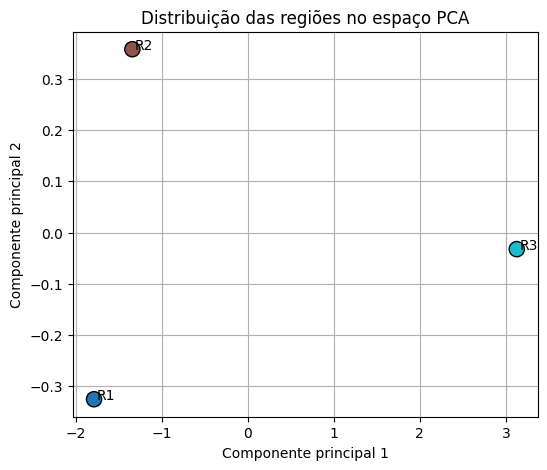

In [12]:
label_img = labels_shapes 
colored = colorize_labels(label_img)

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(colored)
ax.set_title('Regiões rotuladas (base para a análise)')
ax.axis('off')
for region in measure.regionprops(label_img):
    y, x = region.centroid
    ax.text(x, y, f'R{region.label}', color='white', fontsize=10, weight='bold',
            ha='center', va='center')

def region_descriptors_basic(label_img):
    descs = []
    for region in measure.regionprops(label_img):
        area = region.area
        perim = region.perimeter
        circularity = 4 * np.pi * area / (perim**2 + 1e-8)
        bbox = region.bbox
        h, w = bbox[2] - bbox[0], bbox[3] - bbox[1]
        elong = min(h, w) / max(h, w)
        solidity = region.solidity
        descs.append({
            'Região': region.label,
            'Área': area,
            'Perímetro': perim,
            'Circularidade': circularity,
            'Elongação': elong,
            'Solidez': solidity
        })
    return pd.DataFrame(descs)

df_descs = region_descriptors_basic(label_img)
display(df_descs.style.format(precision=3).set_caption("Descritores regionais combinados"))


X = df_descs[['Área', 'Perímetro', 'Circularidade', 'Elongação', 'Solidez']].values
X_std = (X - X.mean(axis=0)) / X.std(axis=0)

pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X_std)

fig, ax = plt.subplots(figsize=(6, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(df_descs)))
ax.scatter(X_pca[:, 0], X_pca[:, 1], s=120, color=colors, edgecolor='black')
for i, row in df_descs.iterrows():
    ax.text(X_pca[i, 0] + 0.03, X_pca[i, 1], f"R{int(row['Região'])}", fontsize=10)
ax.set_xlabel('Componente principal 1')
ax.set_ylabel('Componente principal 2')
ax.set_title('Distribuição das regiões no espaço PCA')
ax.grid(True)